In [ ]:
# script que implementa FinaleToolkit para análisis fragmentómico
# https://github.com/epifluidlab/FinaleToolkit
# autora: suarezhs@uoc.edu

# Importar datos

In [13]:
# working directory to root folder
import os
import pandas as pd

# fragment lengths
df_fraglen_all = pd.read_excel("data_fragment_length_nlsclc_colon.xlsx")
print(df_fraglen_all.head())

   min  max  count         sample      rel_freq  scaled_freq cancer_type
0   65   65      4  L-25000049_S4  1.515868e-07    -0.854557       NSCLC
1   66   66    870  L-25000049_S4  3.297013e-05    -0.677005       NSCLC
2   67   67    987  L-25000049_S4  3.740405e-05    -0.639620       NSCLC
3   68   68   1173  L-25000049_S4  4.445283e-05    -0.674418       NSCLC
4   69   69  10416  L-25000049_S4  3.947321e-04     0.690074       NSCLC


In [35]:
# coger las filas donde col sample contiene Sera
df_fraglen_all.loc[df_fraglen_all['sample'].str.contains("Sera", case=False, na=False),'sample'].value_counts()

sample
histoSeraseq0-5      126
histoSeraseqWT       126
histoSeraseq1(1)     126
histoSeraseq2-5      126
histoSeraseqWT(1)    126
histoSeraseq05       126
Name: count, dtype: int64

In [8]:
# endmotifs
df_endmot_all = pd.read_excel("data_endmotif_nlsclc_colon.xlsx")
print(df_endmot_all.head())

  motif      freq         sample cancer_type
0  AAAA  0.010040  L-25000063_S1       NSCLC
1  AAAC  0.003083  L-25000063_S1       NSCLC
2  AAAG  0.004791  L-25000063_S1       NSCLC
3  AAAT  0.004994  L-25000063_S1       NSCLC
4  AACA  0.003264  L-25000063_S1       NSCLC


In [34]:
df_endmot_all.loc[df_endmot_all['sample'].str.contains("Sera", case=False, na=False),'sample'].value_counts()

sample
Seraseq2-5      256
Seraseq05       256
SeraseqWT(1)    256
Seraseq0-5      256
SeraseqWT       256
Seraseq1(1)     256
Name: count, dtype: int64

In [39]:
# excluir muestas Seraseq
df_fraglen = df_fraglen_all[~df_fraglen_all['sample'].str.contains("Sera", case=False, na=False)].copy()
#df_fraglen.loc[df_fraglen['sample'].str.contains("Sera", case=False, na=False),'sample'].value_counts() # OK!

df_endmot = df_endmot_all[~df_endmot_all['sample'].str.contains("Sera", case=False, na=False)].copy()
#df_endmot.loc[df_endmot['sample'].str.contains("Sera", case=False, na=False),'sample'].value_counts() # OK!

# Análisis

## PCA colon vs NSCL

In [40]:
num_muestras_tumor = (
    df_fraglen[["sample", "cancer_type"]]
    .drop_duplicates()
    .groupby("cancer_type")
    .size()
)

num_muestras_tumor

cancer_type
NSCLC    54
colon    15
dtype: int64

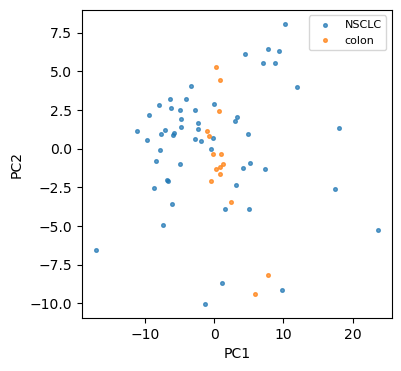

In [43]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

mat_fraglen = (
    df_fraglen.pivot_table(
        index=["sample", "cancer_type"],
        columns="min",        # fragment length
        values="scaled_freq",
        fill_value=0)
)
pca = PCA(n_components=2)
pcs = pca.fit_transform(mat_fraglen)

df_pca = (
    pd.DataFrame(pcs, columns=["PC1", "PC2"], index=mat_fraglen.index)
    .reset_index()
)

# plot
fig, ax = plt.subplots(figsize=(4, 4))

for cancer_type, g in df_pca.groupby("cancer_type"):
    ax.scatter(g.PC1, g.PC2, 
               label=cancer_type, 
               alpha=0.7,
                s = 7
              )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
#ax.set_xticks(np.arange(-20, 30, 10))
#ax.set_yticks(np.arange(-20, 30, 10))
#ax.set_title("PCA – frecuencia escalada")
ax.legend(fontsize=8)

plt.show()

## Longitud de motivos

In [44]:
df_perfil = (
    df_fraglen.groupby(["cancer_type", "min"], as_index=False)["count"].sum()
)

df_perfil["count_per_sample"] = (
    df_perfil["count"] /
    df_perfil["cancer_type"].map(num_muestras_tumor)
)

print(df_perfil.head())

  cancer_type  min  count  count_per_sample
0       NSCLC   50   2597         48.092593
1       NSCLC   51   4162         77.074074
2       NSCLC   52   4344         80.444444
3       NSCLC   53   4741         87.796296
4       NSCLC   54   5508        102.000000


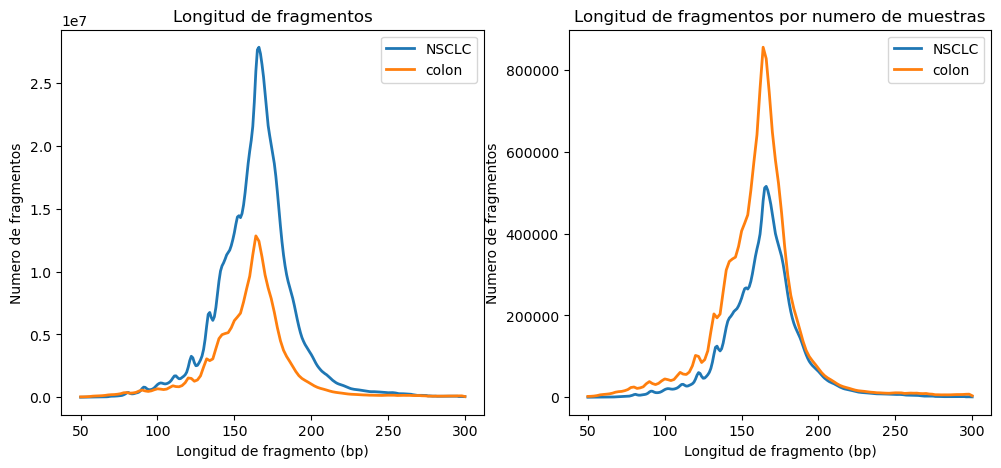

In [45]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for tumor, g in df_perfil.groupby("cancer_type"):
    g = g.sort_values("min")
    ax[0].plot(
        g["min"],
        g["count"],
        label=tumor,
        linewidth=2
    )

ax[0].set_xlabel("Longitud de fragmento (bp)")
ax[0].set_ylabel("Numero de fragmentos")
ax[0].set_title("Longitud de fragmentos")
ax[0].legend()

for tumor, g in df_perfil.groupby("cancer_type"):
    g = g.sort_values("min")
    ax[1].plot(
        g["min"],
        g["count_per_sample"],
        label=tumor,
        linewidth=2
    )

ax[1].set_xlabel("Longitud de fragmento (bp)")
ax[1].set_ylabel("Numero de fragmentos")
ax[1].set_title("Longitud de fragmentos por numero de muestras")
ax[1].legend()

plt.show()

In [46]:
df_perfil.head()

,cancer_type,min,count,count_per_sample
0,NSCLC,50,2597,48.092593
1,NSCLC,51,4162,77.074074
2,NSCLC,52,4344,80.444444
3,NSCLC,53,4741,87.796296
4,NSCLC,54,5508,102.000000


/var/folders/3n/cmq87plj5zx43b8bbf_fdhth0000gp/T/ipykernel_9769/1849725221.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.loc[g["count"].idxmax(), "min"])


['NSCLC (moda = 165.0 bp)', 'colon (moda = 164.0 bp)']


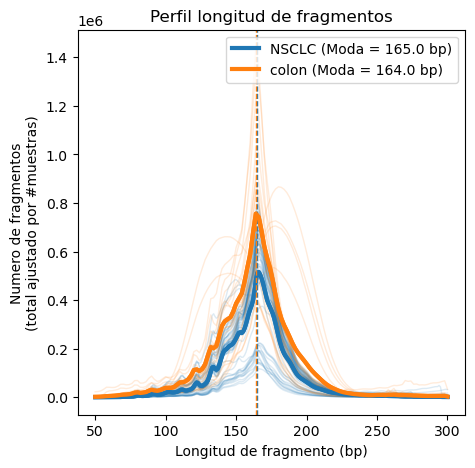

In [720]:
colors_tumor = {
    "NSCLC": "tab:blue",
    "colon": "tab:orange"
}

# perfil por muestra
df_perfil_sample = (
    df_fraglen
    .groupby(["cancer_type", "sample", "min"], as_index=False)["count"]
    .sum()
)

# media longitud de fragmentos
mean_fraglen = (
    df_perfil_sample
    .groupby("cancer_type")
    .apply(lambda g: np.average(g["min"], weights=g["count"]), include_groups=False)
)

# moda longitud de fragmentos
mode_fraglen = (
    df_perfil_sample
    .groupby("cancer_type", group_keys=False)
    .apply(lambda g: g.loc[g["count"].idxmax(), "min"])
)

legend_labels = []

for tumor, x in mode_fraglen.items():
    legend_labels.append(f"{tumor} (moda = {x:.1f} bp)")

print(legend_labels)

fig, ax = plt.subplots(figsize=(5, 5))

# perfil por muestra
for (tumor, sample), g in df_perfil_sample.groupby(["cancer_type", "sample"]):
    g = g.sort_values("min")
    ax.plot(
        g["min"],
        g["count"],
        color=colors_tumor[tumor],
        alpha=0.15,       # faint
        linewidth=1
    )

# perfil medio por tumor (ajustado a numero de muestras)
for tumor, g in df_perfil.groupby("cancer_type"):
    g = g.sort_values("min")
    ax.plot(
        g["min"],
        g["count_per_sample"],
        color=colors_tumor[tumor],
        linewidth=3,
        label="_nolegend_"
    )

# lineas media longitud fragmento
for tumor, g in df_perfil.groupby("cancer_type"):
    g = g.sort_values("min")
    ax.plot(
        g["min"],
        g["count_per_sample"],
        color=colors_tumor[tumor],
        linewidth=3,
        label=f"{tumor} (Moda = {mode_fraglen[tumor]:.1f} bp)"
    )

    ax.axvline(
        mode_fraglen[tumor],
        color=colors_tumor[tumor],
        linestyle="--",
        linewidth=1,
        label="_nolegend_"
    )

ax.set_xlabel("Longitud de fragmento (bp)")
ax.set_ylabel("Numero de fragmentos\n(total ajustado por #muestras)")
ax.set_title("Perfil longitud de fragmentos")
ax.legend()

plt.show()

## End-motifs

/Users/sarasuarez/miniconda3/envs/fragmentomics/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


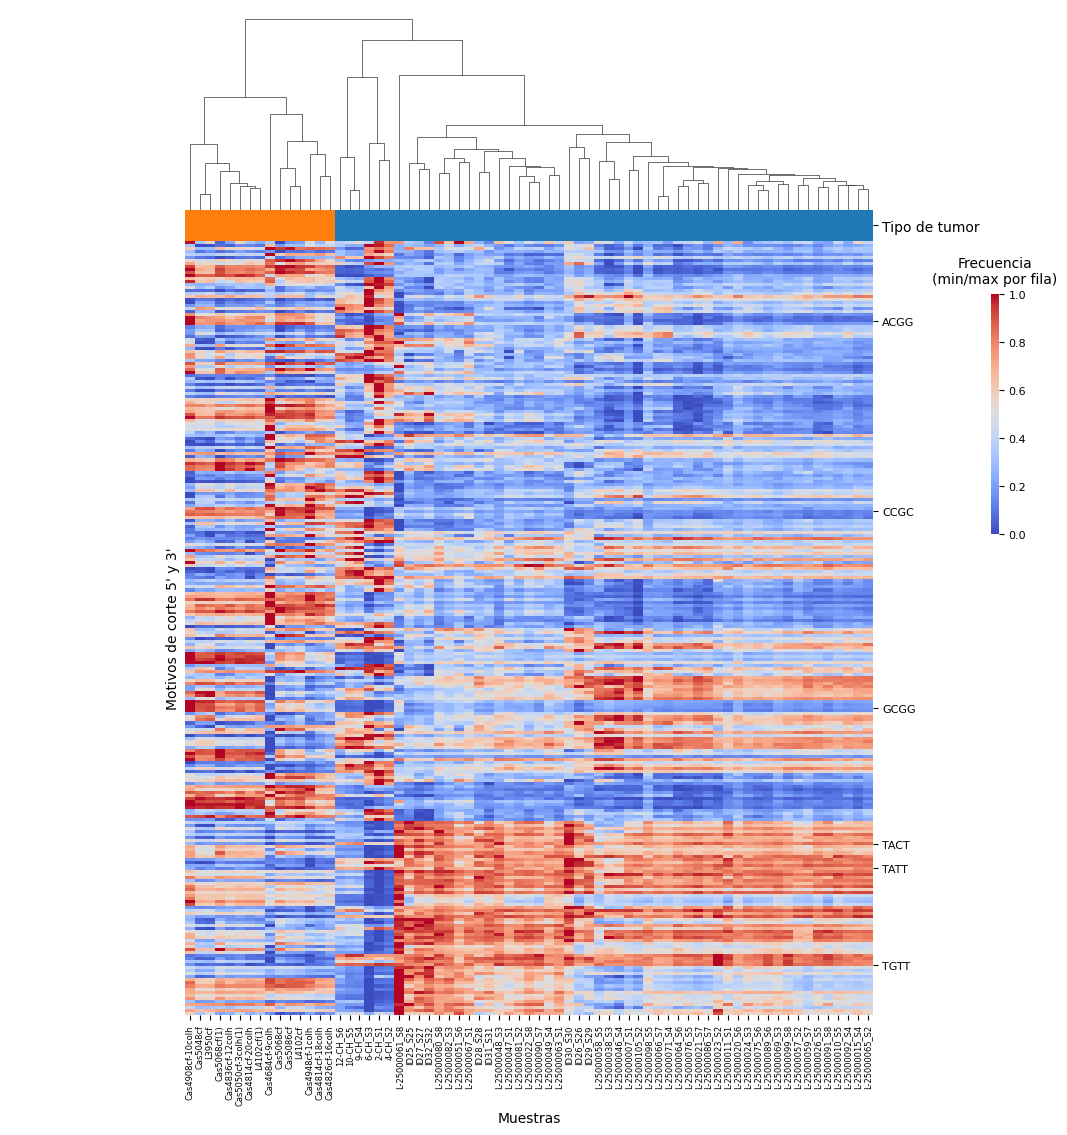

In [88]:
# heatmap
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# matrix
heat_matrix = df_endmot.pivot(index="motif", columns="sample", values="freq")

# color
colors_tumor = {
    "NSCLC": "tab:blue",
    "colon": "tab:orange"
}
col_colors = df_endmot.drop_duplicates("sample").set_index("sample")["cancer_type"].map(colors_tumor)
# leyenda
col_colors.name = "Tipo de tumor"

# clustered heatmap
heat = sns.clustermap(
    heat_matrix,
    col_cluster=True,        
    row_cluster=False,
    col_colors=col_colors,
    cmap="coolwarm",
    standard_scale=0, # normalizar filas (max freq = 1 vs min freq = 0)
    figsize=(10,12),
    xticklabels=True,
    yticklabels=False
    #cbar_kws={"shrink": 0.2}
)

heat.ax_heatmap.tick_params(axis='x', labelsize=6)
heat.ax_heatmap.yaxis.set_label_position("left")
heat.ax_heatmap.set_ylabel("Motivos de corte 5' y 3'")
heat.ax_heatmap.set_xlabel("Muestras")

# nombre filas de motivos representativos
yticks = []
yticklabels = []

# motivos seleccionados - ver siguiente seccion
rep_motifs = [#'CCTG', 'CCCA', 'CCAG', # media NSCLC más alta sin muestras SeraSeq ----- equivalente report (mas abundante en ambos)
              #'AAGG', 'AGGG', 'ATGG', # FC minimo (mas abundante en colon) con muestras SeraSeq
              'TACT', 'TATT', 'TGTT', # FC maximo (rep NSCLC) sin muestras SeraSeq ---- comp. colon report
              'CCGC', 'GCGG', 'ACGG', # FC minimo (rep colon) sin muestras SeraSeq ----- equivalente report
             ]

for i, motif in enumerate(heat_matrix.index):
    if motif in rep_motifs:
        yticks.append(i + 0.5)      # center of the cell
        yticklabels.append(motif)

heat.ax_heatmap.set_yticks(yticks)
heat.ax_heatmap.set_yticklabels(yticklabels, fontsize=8)

# leyenda
heat.ax_cbar.set_aspect(30)
heat.ax_cbar.set_position([0.9, 0.55, 0.2, 0.2]) 
heat.ax_cbar.tick_params(labelsize=8)
heat.ax_cbar.set_title("Frecuencia\n(min/max por fila)", fontsize=10, pad=8)

plt.show()

/var/folders/3n/cmq87plj5zx43b8bbf_fdhth0000gp/T/ipykernel_60721/3386713878.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
/var/folders/3n/cmq87plj5zx43b8bbf_fdhth0000gp/T/ipykernel_60721/3386713878.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
/var/folders/3n/cmq87plj5zx43b8bbf_fdhth0000gp/T/ipykernel_60721/3386713878.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
/var/folders/3n/cmq87plj5zx43b8bbf_fdhth0000gp/T/ipykernel_60721/3386713878.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, 

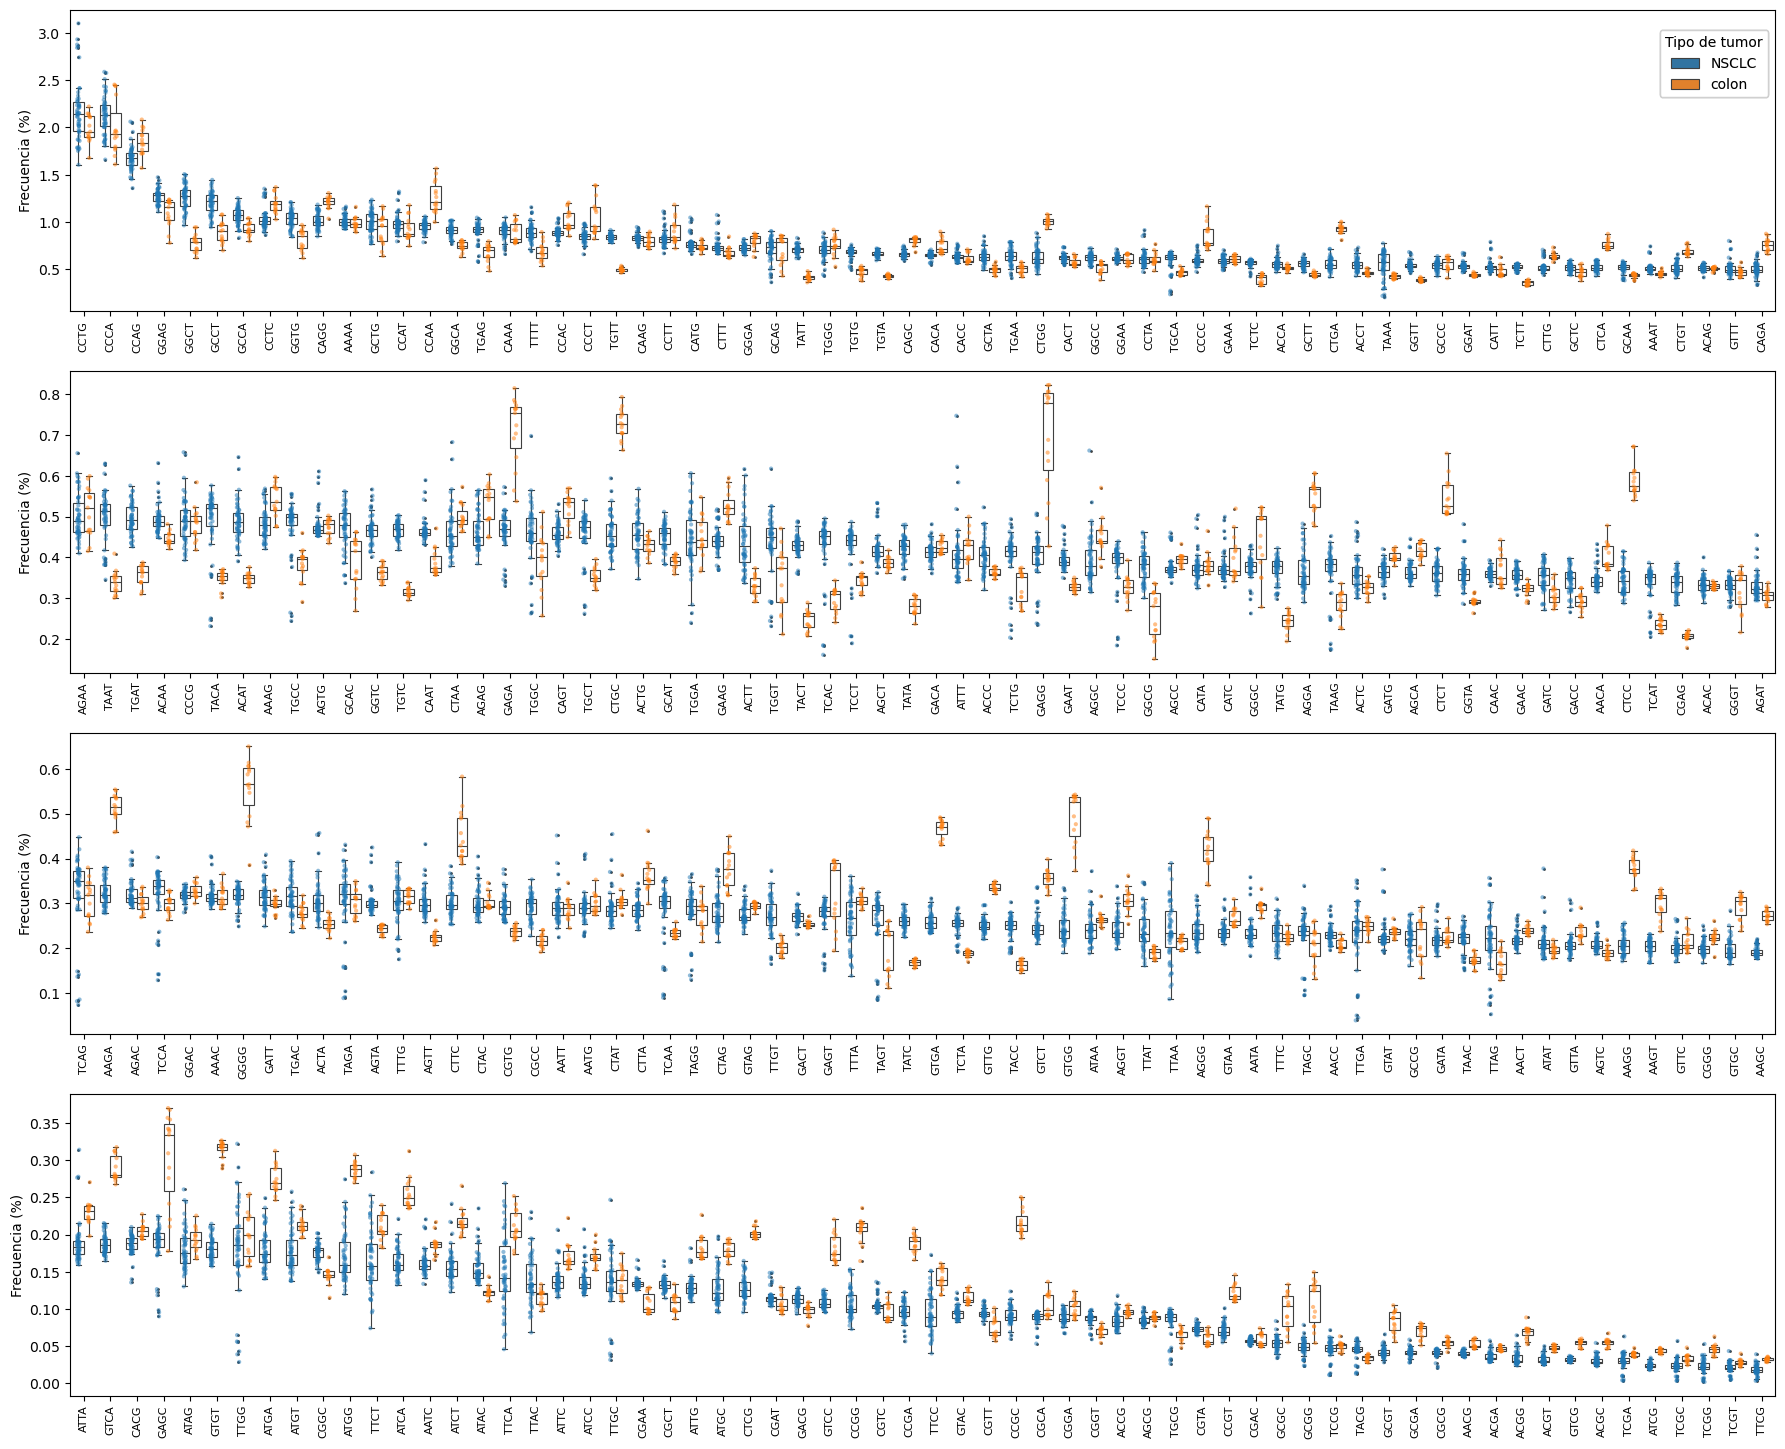

In [48]:
# boxplot motivos diferentes colon vs NSCLC
# porcentaje
df_endmot['percent'] = df_endmot['freq']*100

# ordenar decreciente frecuencia NSCLC
order = (df_endmot[df_endmot["cancer_type"]=="NSCLC"]
         .groupby("motif")["freq"]
         .mean()
         .sort_values(ascending=False)
         .index.tolist())

# Split into 4 chunks of 64 motifs each
chunks = [order[i:i+64] for i in range(0, len(order), 64)]

fig, axes = plt.subplots(4, 1, figsize=(22,18), sharey=False)

for ax, subset in zip(axes, chunks):
    df_sub = df_endmot[df_endmot["motif"].isin(subset)]

    sns.boxplot(data=df_sub,
                x="motif", 
                y="percent",
                hue="cancer_type",
                order=subset,
                ax=ax,
                boxprops=dict(facecolor="none"),
                fliersize=1,
                linewidth=0.8)

    sns.stripplot(data=df_sub,
                  x="motif", 
                  y="percent", 
                  hue="cancer_type",
                  order=subset, 
                  ax=ax,
                  dodge=True,            # aligns with boxplot groups
                  jitter=True,
                  alpha=0.5,             # transparent dots
                  size=3
                 )
    
    ax.legend_.remove()

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles[:2], 
               labels[:2], 
               title="Tipo de tumor",
               loc="right",
               bbox_to_anchor=(0.9,0.85)
              )

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia (%)")

In [49]:
from scipy.stats import mannwhitneyu

results = []

for motif in df_endmot["motif"].unique():
    nsclc_vals = df_endmot[(df_endmot.motif == motif) & 
                               (df_endmot.cancer_type == "NSCLC")]["percent"]
    colon_vals = df_endmot[(df_endmot.motif == motif) & 
                               (df_endmot.cancer_type == "colon")]["percent"]

    mean_n = nsclc_vals.mean()
    mean_c = colon_vals.mean()
    
    # real fold change (ratio)
    foldchange = mean_n / mean_c if mean_c > 0 else np.nan
    
    # log2FC (better for volcano plots)
    #log2FC = np.log2(foldchange) if foldchange > 0 else np.nan
    
    # stats
    stat, p = mannwhitneyu(nsclc_vals, colon_vals, alternative='two-sided')
    
    results.append([motif, mean_n, mean_c, foldchange, 
                    #log2FC, 
                    p])

df_stats = pd.DataFrame(results, 
                        columns=["motif","mean_nsclc","mean_colon",
                                 "foldchange",
                                 #"log2FC",
                                 "p_value"])

In [50]:
# corrijo p-value por test multiples
from statsmodels.stats.multitest import multipletests

df_stats["FDR"] = multipletests(df_stats["p_value"], method="fdr_bh")[1]

df_stats.head()

,motif,mean_nsclc,mean_colon,foldchange,p_value,FDR
0,AAAA,1.009157,0.987544,1.021886,1.560693e-01,1.752357e-01
1,AAAC,0.318038,0.316527,1.004773,8.329310e-01,8.563467e-01
2,AAAG,0.481322,0.541874,0.888254,1.607336e-05,2.587911e-05
3,AAAT,0.512828,0.454645,1.127974,3.414080e-07,7.534521e-07
4,AACA,0.346179,0.404516,0.855784,2.144995e-07,5.084433e-07


In [72]:
# metodo original
# elegir 6 motivos representativos (3 NSCLC>colon (FC>1) vs 3 NSCLC<colon (FC<1) maximizando las medias)
# stat. signif
print(df_stats[df_stats["FDR"] < 0.05].sort_values(by=['mean_nsclc', 'foldchange'], ascending=False).head(n=6))

print(df_stats[df_stats["FDR"] < 0.05].sort_values(by=['foldchange', 'mean_colon'], ascending=True).head(n=6))

    motif  mean_nsclc  mean_colon  foldchange       p_value           FDR  \
94   CCTG    2.168198    1.993113    1.087845  2.554259e-02  3.069907e-02   
84   CCCA    2.132021    1.996389    1.067938  3.954004e-02  4.643234e-02   
82   CCAG    1.678532    1.850948    0.906850  4.490519e-05  6.842696e-05   
162  GGAG    1.272798    1.099468    1.157649  6.268925e-06  1.084355e-05   
167  GGCT    1.263953    0.779627    1.621228  3.989959e-09  2.213417e-08   
151  GCCT    1.200943    0.891889    1.346516  4.688907e-08  1.333734e-07   

     neg_log10_p  color_col  
94      1.592735      black  
84      1.402963      black  
82      4.347703     orange  
162     5.202807      black  
167     8.399032  lightblue  
151     7.328928  lightblue  
    motif  mean_nsclc  mean_colon  foldchange       p_value           FDR  \
89   CCGC    0.090897    0.216366    0.420109  3.989959e-09  2.213417e-08   
154  GCGG    0.048650    0.108857    0.446915  1.727416e-08  5.669466e-08   
26   ACGG    0.0336

In [73]:
# mas frecuente en ambos
# stat. signif
print(df_stats[df_stats["FDR"] < 0.05].sort_values(by=['mean_nsclc', 'foldchange'], ascending=False).head(n=6))

print(df_stats[df_stats["FDR"] < 0.05].sort_values(by=['mean_colon', 'foldchange'], ascending=False).head(n=6))

    motif  mean_nsclc  mean_colon  foldchange       p_value           FDR  \
94   CCTG    2.168198    1.993113    1.087845  2.554259e-02  3.069907e-02   
84   CCCA    2.132021    1.996389    1.067938  3.954004e-02  4.643234e-02   
82   CCAG    1.678532    1.850948    0.906850  4.490519e-05  6.842696e-05   
162  GGAG    1.272798    1.099468    1.157649  6.268925e-06  1.084355e-05   
167  GGCT    1.263953    0.779627    1.621228  3.989959e-09  2.213417e-08   
151  GCCT    1.200943    0.891889    1.346516  4.688907e-08  1.333734e-07   

     neg_log10_p  color_col  
94      1.592735      black  
84      1.402963      black  
82      4.347703     orange  
162     5.202807      black  
167     8.399032  lightblue  
151     7.328928  lightblue  
   motif  mean_nsclc  mean_colon  foldchange       p_value           FDR  \
84  CCCA    2.132021    1.996389    1.067938  3.954004e-02  4.643234e-02   
94  CCTG    2.168198    1.993113    1.087845  2.554259e-02  3.069907e-02   
82  CCAG    1.678532  

In [81]:
# max FC NSCLC o minimo colon maximizando media
# stat. signif
print(df_stats[df_stats["FDR"] < 0.05].sort_values(by=['foldchange', 'mean_nsclc'], ascending=False).head(n=6))

print(df_stats[df_stats["FDR"] < 0.05].sort_values(by=['foldchange', 'mean_colon'], ascending=True).head(n=6))

    motif  mean_nsclc  mean_colon  foldchange       p_value           FDR  \
199  TACT    0.429807    0.246857    1.741119  3.989959e-09  2.213417e-08   
207  TATT    0.706736    0.415086    1.702624  3.989959e-09  2.213417e-08   
239  TGTT    0.840501    0.495788    1.695284  3.989959e-09  2.213417e-08   
98   CGAG    0.337837    0.207369    1.629155  3.989959e-09  2.213417e-08   
167  GGCT    1.263953    0.779627    1.621228  3.989959e-09  2.213417e-08   
236  TGTA    0.663334    0.426636    1.554801  3.989959e-09  2.213417e-08   

     neg_log10_p  color_col  
199     8.399032      black  
207     8.399032      black  
239     8.399032      black  
98      8.399032  lightblue  
167     8.399032  lightblue  
236     8.399032  lightblue  
    motif  mean_nsclc  mean_colon  foldchange       p_value           FDR  \
89   CCGC    0.090897    0.216366    0.420109  3.989959e-09  2.213417e-08   
154  GCGG    0.048650    0.108857    0.446915  1.727416e-08  5.669466e-08   
26   ACGG    0.0336

In [86]:
# motivos seleccionados
rep_motifs = [#'CCTG', 'CCCA', 'CCAG', # media NSCLC más alta sin muestras SeraSeq ----- equivalente report (mas abundante en ambos)
              #'AAGG', 'AGGG', 'ATGG', # FC minimo (mas abundante en colon) con muestras SeraSeq
              'TACT', 'TATT', 'TGTT', # FC maximo (rep NSCLC) sin muestras SeraSeq ---- comp. colon report
              'CCGC', 'GCGG', 'ACGG', # FC minimo (rep colon) sin muestras SeraSeq ----- equivalente report
             ]

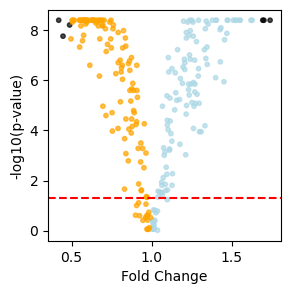

In [99]:
import numpy as np

# asignar colores por filas 
# nsclc azul (FC>1)
df_stats.loc[df_stats['foldchange'] > 1, 'color_col'] = 'lightblue'

# colon naranja (FC<1)
df_stats.loc[df_stats['foldchange'] < 1, 'color_col'] = 'orange'

df_stats.loc[df_stats['motif'].isin(rep_motifs), 'color_col'] = 'black'

# convertir p-value a -log10(p-value) para volcano
df_stats['neg_log10_p'] = -np.log10(df_stats['p_value'])

plt.figure(figsize=(3, 3))
plt.scatter(df_stats['foldchange'], 
            df_stats['neg_log10_p'], 
            s=10,
            c=df_stats['color_col'],
            alpha=0.7)

# linea en signif
plt.axhline(
    y=-np.log10(0.05),
    linestyle='--',
    c = "red"
)

plt.xlabel("Fold Change")
plt.ylabel("-log10(p-value)")

plt.show()

/var/folders/3n/cmq87plj5zx43b8bbf_fdhth0000gp/T/ipykernel_60721/135526230.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
/var/folders/3n/cmq87plj5zx43b8bbf_fdhth0000gp/T/ipykernel_60721/135526230.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)


[Text(0, 0, 'TACT'),
 Text(1, 0, 'TATT'),
 Text(2, 0, 'TGTT'),
 Text(3, 0, 'CCGC'),
 Text(4, 0, 'GCGG'),
 Text(5, 0, 'ACGG')]

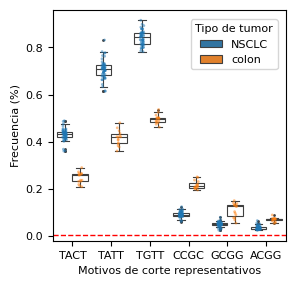

In [100]:
fig, ax = plt.subplots(figsize=(3, 3))

sns.boxplot(data=df_endmot[df_endmot["motif"].isin(rep_motifs)],
            ax = ax,
            x="motif",
            y="percent",
            hue="cancer_type",
            order=rep_motifs,
            boxprops=dict(facecolor="none"),
            fliersize=1,
            linewidth=0.8)

sns.stripplot(data=df_endmot[df_endmot["motif"].isin(rep_motifs)],
              ax = ax,
              x="motif",
              y="percent", 
              hue="cancer_type",
              order=rep_motifs,
              dodge=True,
              jitter=True,
              alpha=0.5,
              size=2) 

ax.legend_.remove()

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2],
          labels[:2],
          title="Tipo de tumor",
          loc="right",
          bbox_to_anchor=(0.99,0.85),
          title_fontsize=8,
          fontsize=8
          )

ax.axhline(y=0.0039, color='r', linestyle='--', linewidth = 1)

ax.set_ylabel("Frecuencia (%)", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

ax.set_xlabel("Motivos de corte representativos", fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)

### MDS

* Al tener ya los archivos .tsv para los motivos de corte de colon, no aplique el siguiente codigo en Python descrito en la documentacion de FinaleToolkit https://github.com/epifluidlab/FinaleToolkit/wiki/3c3d

* Para calcular el MDS, utilizo la formula de la entropia de Shannon normalizada que emplea Finaletoolkit descrita en https://aacrjournals.org/cancerdiscovery/article/10/5/664/2457/Plasma-DNA-End-Motif-Profiling-as-a-Fragmentomic

In [101]:
# algun archivo con freq=0?
# NSCLC - no 0
path = os.path.join(results_endmot, "*.filtered.k4.tsv")  # adjust to your directory

# colon - no o
#path = "../UOC/TFM/00_datos/fragmentomics_colon_lesende/*.tsv"

files_with_zero = []

for f in glob.glob(path):
    df = pd.read_csv(f, sep="\t", header=None, names=["motif","freq"])
    
    # ver si algun motivo - freq=0
    if (df["freq"] == 0).any():
        files_with_zero.append(os.path.basename(f))

# imprimir si hay 0s o si no
if files_with_zero:
    print("Files containing frequency = 0:")
    for file in files_with_zero:
        print(" -", file)
else:
    print("No files contain frequency = 0")

No files contain frequency = 0


In [102]:
# funcion para calcular MDS en NSCLS y colon
import re
import math

path_endmot_nsclc = os.path.join(results_endmot, "*.filtered.k4.tsv") 
path_endmot_colon = "../UOC/TFM/00_datos/fragmentomics_colon_lesende/*.tsv"
# hay que especificar los archivos de 4-mer (histo-fraglen y 2-2mer)
# if not os.path.basename(f).startswith(("histo", "2"))
k = 4
max_entropy = math.log(4**k)

# lista para guardar calculos
records = []

def compute_MDS(file, cancer_type):
    samplename = re.sub(r'\.(bam\.tsv|filtered\.k4\.tsv)$', '', os.path.basename(file))
    df = pd.read_csv(file, sep="\t", header=None, names=["motif","freq"])

    p = df["freq"].values
    h = -np.sum(p * np.log(p)) # entropia
    mds_norm = h / max_entropy

    # guardar resultados en lista
    records.append([samplename, mds_norm, cancer_type])

In [106]:
# calcular MDS aplicando la formula a cada muestra
for f in glob.glob(path_endmot_nsclc):
    compute_MDS(f, "NSCLC")

for f in glob.glob(path_endmot_colon):
    samplename = os.path.basename(f)
    # ignorar tsv para el histograma o 2-mer endmotifs
    if samplename.startswith(("histo", "2")):
        continue
    # ignorar SeraSeq
    if "sera" in samplename.lower():
        continue
    compute_MDS(f, "colon")

# transformar lista en df
df_mds = pd.DataFrame(records, columns=["sample", "mds", "cancer_type"])

# excluir muestras de referencia
ctrl_samples = ["CTRL-M-BL-CHUIMI_S7", "CTRL-F-BL-CHUIMI_S8"]

df_mds = df_mds[~df_mds["sample"].isin(ctrl_samples)]
print(df_mds)

                sample       mds cancer_type
0        L-25000063_S1  0.955832       NSCLC
1              2-CH_S1  0.941417       NSCLC
2        L-25000090_S7  0.954018       NSCLC
3        L-25000066_S7  0.950604       NSCLC
4        L-25000057_S2  0.950554       NSCLC
..                 ...       ...         ...
66             L4102cf  0.956916       colon
67  Cas5050cf-3colh(1)  0.957988       colon
68          L4102cf(1)  0.957343       colon
69    Cas4814cf-18colh  0.949667       colon
70    Cas4826cf-16colh  0.951889       colon

[69 rows x 3 columns]


/var/folders/3n/cmq87plj5zx43b8bbf_fdhth0000gp/T/ipykernel_60721/537184929.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
/var/folders/3n/cmq87plj5zx43b8bbf_fdhth0000gp/T/ipykernel_60721/537184929.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)


[Text(0, 0, 'NSCLC'), Text(1, 0, 'colon')]

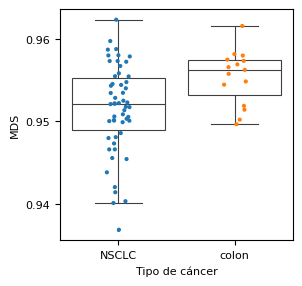

In [107]:
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, NullLocator

# box MDS
fig, ax = plt.subplots(figsize=(3, 3))

# box
sns.boxplot(data=df_mds,
            ax = ax,
            x="cancer_type",
            y="mds",
            hue="cancer_type",
            boxprops=dict(facecolor="none"),
            fliersize=1,
            linewidth=0.8)

# dots
sns.stripplot(data=df_mds,
              ax = ax,
              x="cancer_type",
              y="mds", 
              hue="cancer_type",
              jitter=True,
              alpha=1,
              size=3) 

ax.yaxis.set_major_locator(MultipleLocator(0.01)) # 2 decimales
ax.set_ylabel("MDS", fontsize=8)
ax.set_xlabel("Tipo de cáncer", fontsize=8)

ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)

In [108]:
df_mds.sort_values(by="mds", ascending=True).head()

,sample,mds,cancer_type
27,6-CH_S3,0.936876,NSCLC
13,9-CH_S4,0.940115,NSCLC
5,10-CH_S5,0.940335,NSCLC
1,2-CH_S1,0.941417,NSCLC
48,4-CH_S2,0.942043,NSCLC


In [109]:
df_mds["cancer_type"].value_counts()

cancer_type
NSCLC    54
colon    15
Name: count, dtype: int64

In [110]:
mds_colon = df_mds.loc[df_mds["cancer_type"] == "colon", "mds"]
mds_nsclc = df_mds.loc[df_mds["cancer_type"] == "NSCLC", "mds"]

u_stat, p_value = mannwhitneyu(
    mds_colon,
    mds_nsclc,
    alternative="two-sided"
)

print(f"Mann–Whitney estadístico = {u_stat:.2f}")
print(f"p-valor = {p_value:.3e}")

Mann–Whitney estadístico = 578.00
p-valor = 1.209e-02
